```{contents}
```

## Demonstration

Training RBF Network...
Epoch 0, Loss: 0.6428
Epoch 200, Loss: 0.5404
Epoch 200, Loss: 0.5404
Epoch 400, Loss: 0.5404
Epoch 400, Loss: 0.5404
Epoch 600, Loss: 0.5404
Epoch 600, Loss: 0.5404
Epoch 800, Loss: 0.5404
Epoch 800, Loss: 0.5404


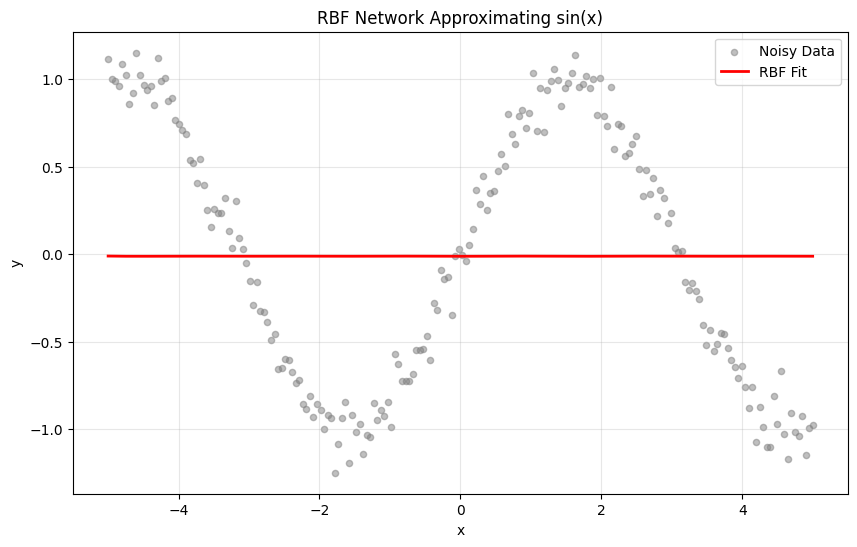


Final MSE Loss: 0.540400
Number of RBF centers: 20
Input range: [-5.0, 5.0]


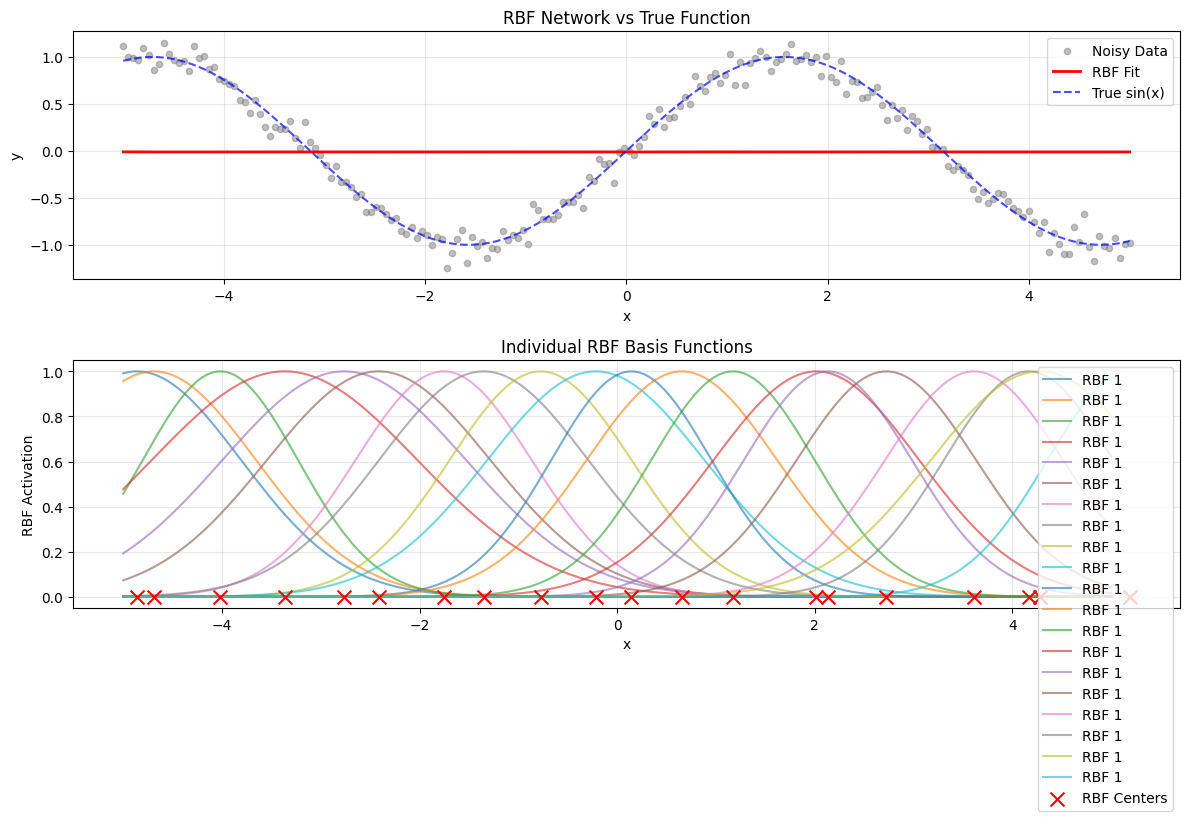

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate sample data
x = np.linspace(-5, 5, 200).reshape(-1, 1)
y = np.sin(x) + 0.1 * np.random.randn(*x.shape)

x_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)

# 2. Simple RBF layer
class RBFLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.centers = nn.Parameter(torch.linspace(-5, 5, out_features).view(out_features, 1))
        self.sigma = nn.Parameter(torch.ones(out_features))

    def forward(self, x):
        x_exp = x.unsqueeze(1)
        dist = (x_exp - self.centers.T) ** 2
        return torch.exp(-dist / (2 * self.sigma ** 2))

# 3. RBF Network
class RBFNet(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.rbf = RBFLayer(in_features, hidden_features)
        self.linear = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        phi = self.rbf(x)
        return self.linear(phi)

# 4. Train the model
model = RBFNet(1, 20, 1)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Training RBF Network...")
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# 5. Generate predictions for plotting (fix the shape issue)
model.eval()
with torch.no_grad():
    y_pred = model(x_train)

# Fix the shape mismatch by properly reshaping
x_plot = x.flatten()  # Convert (200, 1) to (200,)
y_plot = y.flatten()  # Convert (200, 1) to (200,)
y_pred_plot = y_pred.detach().numpy().flatten()  # Convert (200, 1) to (200,)

# 6. Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x_plot, y_plot, color='gray', alpha=0.5, label='Noisy Data', s=20)
plt.plot(x_plot, y_pred_plot, color='red', linewidth=2, label='RBF Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("RBF Network Approximating sin(x)")
plt.grid(True, alpha=0.3)
plt.show()

# 7. Show some statistics
final_loss = criterion(y_pred, y_train).item()
print(f"\nFinal MSE Loss: {final_loss:.6f}")
print(f"Number of RBF centers: {model.rbf.centers.shape[0]}")
print(f"Input range: [{x_plot.min():.1f}, {x_plot.max():.1f}]")

# 8. Visualize RBF centers and their influence
plt.figure(figsize=(12, 8))

# Plot 1: Data and fit
plt.subplot(2, 1, 1)
plt.scatter(x_plot, y_plot, color='gray', alpha=0.5, label='Noisy Data', s=20)
plt.plot(x_plot, y_pred_plot, color='red', linewidth=2, label='RBF Fit')
plt.plot(x_plot, np.sin(x_plot), color='blue', linestyle='--', alpha=0.7, label='True sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title("RBF Network vs True Function")
plt.grid(True, alpha=0.3)

# Plot 2: RBF activations
plt.subplot(2, 1, 2)
with torch.no_grad():
    rbf_activations = model.rbf(x_train).detach().numpy()
    centers = model.rbf.centers.detach().numpy().flatten()
    
# Plot individual RBF functions
for i in range(min(10, rbf_activations.shape[1])):  # Show first 10 RBFs
    plt.plot(x_plot, rbf_activations[:, i], alpha=0.6, label=f'RBF {i+1}' if i < 5 else '')

# Mark centers
plt.scatter(centers, np.zeros_like(centers), color='red', s=100, marker='x', 
           zorder=5, label='RBF Centers')
plt.xlabel('x')
plt.ylabel('RBF Activation')
plt.title("Individual RBF Basis Functions")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()